# 3b — Spatial deprivation score & survey-cluster representativity

**Step 3b — the validation of the sampling.** This notebook does two things, in sequence:

- **Part A (§1–§5)** distils the morphometrics of notebook `3a` into a graded, reproducible
  **spatial deprivation score** per building (**−1 … 8**): nine directional flags — each signed by theory, following
  the *spatial signals of poverty* literature [1,2] — computed on spatially
  smoothed signals and summed;
- **Part B (§6–§12)** uses that score to measure the **diversity and representativity of the built
  environments sampled by the survey clusters** (drawn in notebook `2`), against two frames: the **AOI**
  (the frame of the HDSS) and **Yopougon as a whole** (the frame of an eventual expansion of the HDSS and
  its surveys).

The score stays **granular** throughout: no threshold is applied and nothing is classified as "deprived" here —
the graded measure itself is the reference. Its construction was developed and tested against field
observations of informal settlements in the study area.


In [1]:
import warnings
from pandas.errors import SettingWithCopyWarning
warnings.filterwarnings('ignore', category=SettingWithCopyWarning)   # benign chained-assignment notices (geopandas)
warnings.filterwarnings('ignore', category=RuntimeWarning)           # NaN-aware numpy operations on empty/all-NaN slices
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from libpysal import graph
from pathlib import Path
from rasterio.transform import rowcol
from scipy.spatial import cKDTree
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix

In [2]:
notebook_dir = Path().resolve()
local_crs = 2041          # Abidjan 1987 / UTM 30N — metric, used for all area work

# GITHUB-EXPORT COPY: paths adjusted for the trimmed data/ folder shipped alongside this notebook.
# AOI_FP still points outside this folder (../_GIS/) — not included in this export; see README.md.
AOI_FP      = notebook_dir.parent / "_GIS/HomeMade/new_aoi.shp"                 # study area
CLUSTERS_FP = notebook_dir / "data/raw/_GRAPPES_final-REF.gpkg"     # was ../_GIS/HomeMade/ — copied into data/raw/ for this export
BUILDINGS_FP = "data/output/buildings_spatial-deprivation-scored.parquet"  # was .gpkg — converted to GeoParquet for size (see data/README.md)
HABITAT_REF_FP = "data/raw/sampling_habitat-areas_reference.gpkg"               # archival: the habitat framework it used (notebook 2)


---

## Part A — the spatial deprivation score

Measures the urban fabric with a transparent, **directional rule-based scorecard**. Rather than asking an
unsupervised algorithm to *discover* groups and then labelling them, the domain knowledge is encoded directly:
each building receives a small set of **flags**, each with a theory-justified sign, summed into an
**spatial deprivation score**. Blocks (from notebook `1`) are then summarised by the mean score of their buildings.

**Inputs:** building morphometrics, tessellation and street nodes from notebook `3a`; blocks from notebook `1`;
a night-lights raster; and OSM waterways. **Outputs:** scored buildings and block mean scores, used by
Part B below.

**Inspiration — spatial signals of poverty [1,2].** This follows the line of work by
**Taubenböck, Wurm and colleagues [1,2]** showing that deprived / informal settlements have a *characteristic
morphology* detectable from Earth observation and building morphometrics — high built density, irregular /
organic layout, small and mis-aligned structures, poor street access, low night-time light, and hazardous-
location signals (here, proximity to water). We translate those spatial signals of poverty into **nine
building-level flags**.

**Score (range −1 to 8):**

```
score =  flag_meandev + flag_nnb50m + flag_stralign + flag_diststr  -  flag_ndmesh  +  flag_lowntl  +  flag_small  +  flag_water  +  flag_lowstd
```

| flag | fires when | signal |
|---|---|---|
| `flag_meandev`  **(+1)**| neighbour-alignment deviation (KNN-4) in the **high** tail | irregular layout → higher deprivation |
| `flag_nnb50m`   **(+1)**| buildings within 50 m in the **high** tail | crowding → higher deprivation |
| `flag_stralign` **(+1)**| deviation from the nearest street in the **high** tail | not street-aligned → higher deprivation |
| `flag_diststr`  **(+1)**| distance to nearest street in the **high** tail | poor access → higher deprivation |
| `flag_ndmesh`   **(-1)**| nearest-node meshedness in the **high** tail | planned grid → **lower** deprivation (**−1**) |
| `flag_lowntl`   **(+1)**| night-lights (VIIRS) in the **low** tail | dark populated area → higher deprivation |
| `flag_small`    **(+1)**| building footprint in the **low** tail | small structures → higher deprivation |
| `flag_water`    **(+1)**| distance to nearest waterway in the **low** tail | near water = hazardous/marginal → higher deprivation |
| `flag_lowstd`   **(+1)**| neighbourhood **std of footprint area** in the **low** tail | uniform building sizes → higher deprivation |

**Two knobs** (the defaults are the configuration retained after empirical testing against field observations):
- **`FLAG_MODE`** — the tail cut: `quartile` (Q3/Q1 = 75/25) vs **`quintile` (80/20)** vs `tertile`.
- **`SMOOTHING`** — **`spatial_lag`** contextualises each feature over the tessellation neighbourhood
  (interquartile-mean, order `CONTEXT_ORDER`), *in the same spirit as the numerical taxonomy of urban form of Fleischmann and colleagues [3]*,
  before flagging — which de-noises the raw per-building flags. `raw` = no smoothing.

> **Note:** the tail cuts are *sample-relative* percentiles — they must be recomputed for a different city
> or a materially different study area (e.g. the future HDSS extension).

## Configuration

In [3]:
export_crs      = 2041
STUDY_AREA_KEY  = 'yopou'
CONTEXT_ORDER   = 3                 # tessellation topological steps for the spatial-lag smoothing
BUFFER_M        = 500               # map extent = study area + this buffer

FLAG_MODE          = 'quintile'        # 'quartile' (75/25) | 'quintile' (80/20) | 'tertile' (66.7/33.3)
SMOOTHING          = 'spatial_lag'     # 'spatial_lag' (Fleischmann-style IQ-mean) | 'raw'

# tail percentiles per FLAG_MODE (high-tail cut, low-tail cut)
HI, LO = {'quartile': (75, 25), 'quintile': (80, 20), 'tertile': (200/3, 100/3)}[FLAG_MODE]

# GITHUB-EXPORT COPY: BDG_FP/TESS_FP were single .gpkg files spanning all 4 communes (119MB/251MB) —
# too large for GitHub even after restricting to Yopougon-Attécoubé. Converted to GeoParquet, already
# restricted to Yopougon-Attécoubé (identical to the population this notebook actually scores — see
# the nearest-block scoping below), and split into parts to stay under 25MB each; read + concatenated
# in the cells that use them. WW_LINE/WW_POLY still point outside this folder (../_GIS/), not included.
BDG_FP   = ['data/temp/Abidjan_Building_Footprints_SelAOI_momepy_bdg_part1of2.parquet',
            'data/temp/Abidjan_Building_Footprints_SelAOI_momepy_bdg_part2of2.parquet']
TESS_FP  = [f'data/temp/Abidjan_Building_Footprints_SelAOI_momepy_tess_part{i}of4.parquet' for i in range(1, 5)]
NODES_FP = 'data/temp/nodes.gpkg'
BLOCKS_FP= 'data/temp/_check-blocks_geom_manual-corr.gpkg'
NTL_FP   = 'data/raw/NightLights_SelAOI_154m_dry.tif'
WW_LINE  = '../_GIS/OSM_2025-04-08.shp/gis_osm_waterways_free_1.shp'
WW_POLY  = '../_GIS/OSM_2025-04-08.shp/gis_osm_water_a_free_1.shp'
print(f'FLAG_MODE={FLAG_MODE} (hi>={HI:.0f}th, lo<={LO:.0f}th)   SMOOTHING={SMOOTHING}')

FLAG_MODE=quintile (hi>=80th, lo<=20th)   SMOOTHING=spatial_lag


## 1. Scope & raw building signals

Eight raw per-building signals (five from `3a_Morphometrics` + nearest-node meshedness, + nearest VIIRS pixel +
distance to the nearest OSM waterway). The *ninth* signal — neighbourhood footprint heterogeneity (std of
building area) — needs the tessellation contiguity graph, so it is computed in §2.

In [4]:
aoi = gpd.read_file(AOI_FP).explode(index_parts=False).reset_index(drop=True).to_crs(local_crs)
blocks_all = gpd.read_file(BLOCKS_FP).to_crs(export_crs)
blocks = blocks_all[blocks_all['area'].astype(str).str.lower().str.contains(STUDY_AREA_KEY)].reset_index(drop=True)
blocks['block_id'] = blocks.index

bld_all = pd.concat([gpd.read_parquet(fp) for fp in BDG_FP], ignore_index=True).to_crs(export_crs)  # was read_file (single .gpkg)
bc_all = gpd.GeoDataFrame({'row': np.arange(len(bld_all))}, geometry=bld_all.geometry.centroid, crs=bld_all.crs)

# ── study-area SCOPE: nearest-block area label, NOT strict within() ──────────────────────────────
# `_check-blocks_geom_manual-corr.gpkg` is manually QGIS-edited and PARTIAL by design (site-visited
# blocks only; the user prunes uninhabited blocks over time). If scoping used strict within(blocks),
# a building would silently fall out of the scored population whenever the block it used to sit in
# was removed — even though it is still genuinely inside the study area / AOI. That block-editing is
# legitimate for the BLOCK-LEVEL aggregate (a building with no retained block shouldn't count toward a
# block mean), but must not shrink the BUILDING-level population used for the representativity audit,
# whose reference area is `new_aoi.shp` (Part B), not the blocks. Nearest-block classification is
# robust to individual blocks being dropped, as long as some blocks of that area remain nearby.
_nearest = (gpd.sjoin_nearest(bc_all[['row', 'geometry']], blocks_all[['area', 'geometry']],
                              how='left', distance_col='_d')
            .drop_duplicates('row').sort_values('row'))
in_scope = _nearest['area'].astype(str).str.lower().str.contains(STUDY_AREA_KEY).to_numpy()

bld = bld_all.iloc[in_scope].reset_index(drop=True)
bcent = gpd.GeoDataFrame(geometry=bld.geometry.centroid, crs=bld.crs)

# ── block_id: STRICT within() match, for the block-level export only ────────────────────────────
# A building whose block was removed keeps its building-level score but gets block_id = NaN (excluded
# only from the block-level mean-score aggregate in §5, not from any building-level count).
_bc = gpd.GeoDataFrame({'row': np.arange(len(bld))}, geometry=bcent.geometry, crs=bcent.crs)
_hit = (gpd.sjoin(_bc[['row', 'geometry']], blocks[['block_id', 'geometry']], how='left', predicate='within')
        .drop_duplicates('row').sort_values('row'))
bld['block_id'] = _hit['block_id'].to_numpy()

# nearest-node meshedness
nodes = gpd.read_file(NODES_FP)
tree = cKDTree(np.c_[nodes['x'], nodes['y']])
_, i1 = tree.query(np.c_[bcent.geometry.x, bcent.geometry.y], k=1)
bld['node_meshedness'] = nodes['meshedness'].to_numpy(float)[i1]

# nearest VIIRS pixel
with rasterio.open(NTL_FP) as src:
    arr = src.read(1).astype('float64'); ce = bcent.to_crs(src.crs)
    rr, cc = rowcol(src.transform, ce.geometry.x.to_numpy(), ce.geometry.y.to_numpy())
    rr = np.asarray(rr); cc = np.asarray(cc); ok = (rr >= 0) & (rr < src.height) & (cc >= 0) & (cc < src.width)
    ntl = np.full(len(bld), np.nan); ntl[ok] = arr[rr[ok], cc[ok]]; bld['ntl_nearest'] = ntl

# distance to nearest OSM waterway line / water-body boundary (for the 'near_water' location flag)
from shapely import box
_aoi = box(*bld.total_bounds).buffer(3000)
_wl = gpd.read_file(WW_LINE).to_crs(export_crs); _wl = _wl[_wl.intersects(_aoi)]
_wp = gpd.read_file(WW_POLY).to_crs(export_crs); _wp = _wp[_wp.intersects(_aoi)]
_water = gpd.GeoDataFrame(geometry=gpd.GeoSeries(
    pd.concat([_wl.geometry, _wp.geometry.boundary], ignore_index=True), crs=export_crs).reset_index(drop=True))
_nn = (gpd.sjoin_nearest(bcent.reset_index(), _water, how='left', distance_col='dist_to_waterway')
       .drop_duplicates('index').sort_values('index'))
bld['dist_to_waterway'] = _nn['dist_to_waterway'].to_numpy()

# raw signals -> flag names. Eight of the nine signals (six built-form + night-light, building size,
# proximity to water); the ninth (neighbourhood footprint std) needs the tessellation graph -> section 2.
SIGNALS = {'meandev': 'nb_alignment_knn4', 'nnb50m': 'nnb_50m', 'stralign': 'str_align',
           'diststr': 'dist_to_street', 'ndmesh': 'node_meshedness', 'lowntl': 'ntl_nearest',
           'small_building': 'building_area', 'near_water': 'dist_to_waterway'}
raw = {k: bld[v].to_numpy(float) for k, v in SIGNALS.items()}
print(f'study-area blocks: {len(blocks):,}   buildings: {len(bld):,}')

# Carried forward for the §11 axis audit: raw, unlagged per-building values of the four
# selection-independent habitat axes (Part B re-reads buildings from the export, which keeps only id + score).
raw_axes = pd.DataFrame({'id': bld['id'].to_numpy(),
                         'nnb_50m': raw['nnb50m'], 'building_area': raw['small_building'],
                         'ntl_nearest': raw['lowntl'], 'nb_alignment_knn4': raw['meandev']})


study-area blocks: 3,397   buildings: 200,237


## 2. Spatial-lag smoothing

If `SMOOTHING=='spatial_lag'`, each raw signal is replaced by its **interquartile-mean over the tessellation
contiguity neighbourhood** within `CONTEXT_ORDER` topological steps — the same contextualisation the
building-level clustering uses. This de-noises the per-building flags (raw flags are salt-and-pepper; the
neighbourhood view is what actually separates informal *fabric*). We always compute it; `SMOOTHING` selects which variant feeds the flags.

> **The lag is applied to each of the 8 raw features *separately*, upstream of the flags — not to the score.**
> The loop below replaces every raw signal with its own neighbourhood interquartile-mean; the flags are then
> computed on those smoothed features and only afterwards summed into the spatial deprivation score. The **score itself
> is never spatially lagged** (following the *contextualise-the-characters-then-classify* logic of Fleischmann and colleagues [3]).

The **ninth signal** is also built here: the **standard deviation of building footprint area over the same
order-`CONTEXT_ORDER` neighbourhood** (`Graph.describe(..., statistics=['std'])`). It is *not lagged*, and this
is deliberate. The eight signals above are *per-building* values (my own footprint area, my own distance to
the street, …), so each needs the lag to go from "my value" to "the typical value *around* me". A standard
deviation has **no per-building version** — the spread of *one* building's area is undefined; the signal only
exists over a group. It is therefore computed directly on the order-`CONTEXT_ORDER` neighbourhood and comes out
**pre-smoothed by construction, at the same spatial scale** as the lagged signals. Concretely, it uses the
**very same contiguity graph `g`** as the other variables — so the spatial-lag step is effectively applied **at
the moment the variable is calculated**. the only difference is the summary statistic taken over the
neighbourhood: the lag takes the interquartile **mean** ("the typical value around me"), this signal takes the
**std** ("how varied the values around me are").

In [5]:
tess = pd.concat([gpd.read_parquet(fp, columns=['id', 'geometry']) for fp in TESS_FP],
                 ignore_index=True).to_crs(export_crs)  # was read_file (single .gpkg)
tess = tess[tess['id'].isin(set(bld['id']))].set_index('id').loc[bld['id'].to_numpy()].reset_index()
assert (tess['id'].to_numpy() == bld['id'].to_numpy()).all()
g = graph.Graph.build_contiguity(tess, rook=False).higher_order(CONTEXT_ORDER, lower_order=True).assign_self_weight()
print(f'contiguity graph: {g.n:,} cells   mean neighbours = {g.cardinalities.mean():.1f}')

lag = {}
for k, x in raw.items():
    y = pd.Series(np.where(np.isfinite(x), x, np.nan), index=tess.index)
    y = y.fillna(y.median())
    lag[k] = g.describe(y, q=(25, 75), statistics=['mean'])['mean'].to_numpy()

# 9th signal: neighbourhood footprint heterogeneity — std of building_area over the SAME order-3 graph.
# LOW std = uniform footprints -> higher deprivation (planned / industrial / high-end areas mix sizes).
# Already a neighbourhood statistic -> used as-is in BOTH scorecards (a second lag tested slightly worse).
_ba = pd.Series(np.where(np.isfinite(raw['small_building']), raw['small_building'], np.nan), index=tess.index)
_ba = _ba.fillna(_ba.median())
raw['lowstd'] = lag['lowstd'] = g.describe(_ba, statistics=['std'])['std'].to_numpy()

FEATS = {'raw': raw, 'spatial_lag': lag}[SMOOTHING]

contiguity graph: 200,237 cells   mean neighbours = 47.6


## 3. Flags & spatial deprivation score

Each of the nine signals becomes a binary flag at its `FLAG_MODE` tail (high or low, per the theory-given
direction); the flags are summed — meshedness *subtracted* — into the building score (**−1 … 8**).


In [6]:
def score_from(F, hi, lo):
    ge = lambda x, q: (x >= np.nanpercentile(x, q)).astype(int)   # NaN -> 0
    le = lambda x, q: (x <= np.nanpercentile(x, q)).astype(int)
    flags = dict(flag_meandev=ge(F['meandev'], hi), flag_nnb50m=ge(F['nnb50m'], hi),
                 flag_stralign=ge(F['stralign'], hi), flag_diststr=ge(F['diststr'], hi),
                 flag_ndmesh=ge(F['ndmesh'], hi), flag_lowntl=le(F['lowntl'], lo),
                 flag_small=le(F['small_building'], lo), flag_water=le(F['near_water'], lo),
                 flag_lowstd=le(F['lowstd'], lo))
    s = (flags['flag_meandev'] + flags['flag_nnb50m'] + flags['flag_stralign'] + flags['flag_diststr']
         - flags['flag_ndmesh'] + flags['flag_lowntl'] + flags['flag_small'] + flags['flag_water']
         + flags['flag_lowstd'])
    return s, flags

bld['score'], _flags = score_from(FEATS, HI, LO)
for fn, fv in _flags.items(): bld[fn] = fv
print('building score distribution:'); print(bld['score'].value_counts().sort_index().to_string())

building score distribution:
score
-1    16995
 0    54148
 1    50960
 2    32308
 3    19992
 4    12799
 5     8340
 6     4009
 7      660
 8       26


## 4. Building-level map — study area + 500 m

The graded score over the full scored extent (the notebook-`1`/`3a` study area + 500 m). The AOI — the survey
frame audited in Part B — is drawn dotted for reference. The palette is clamped to −1..5: scores 6–8 are rare
and would otherwise wash out the deprived end.


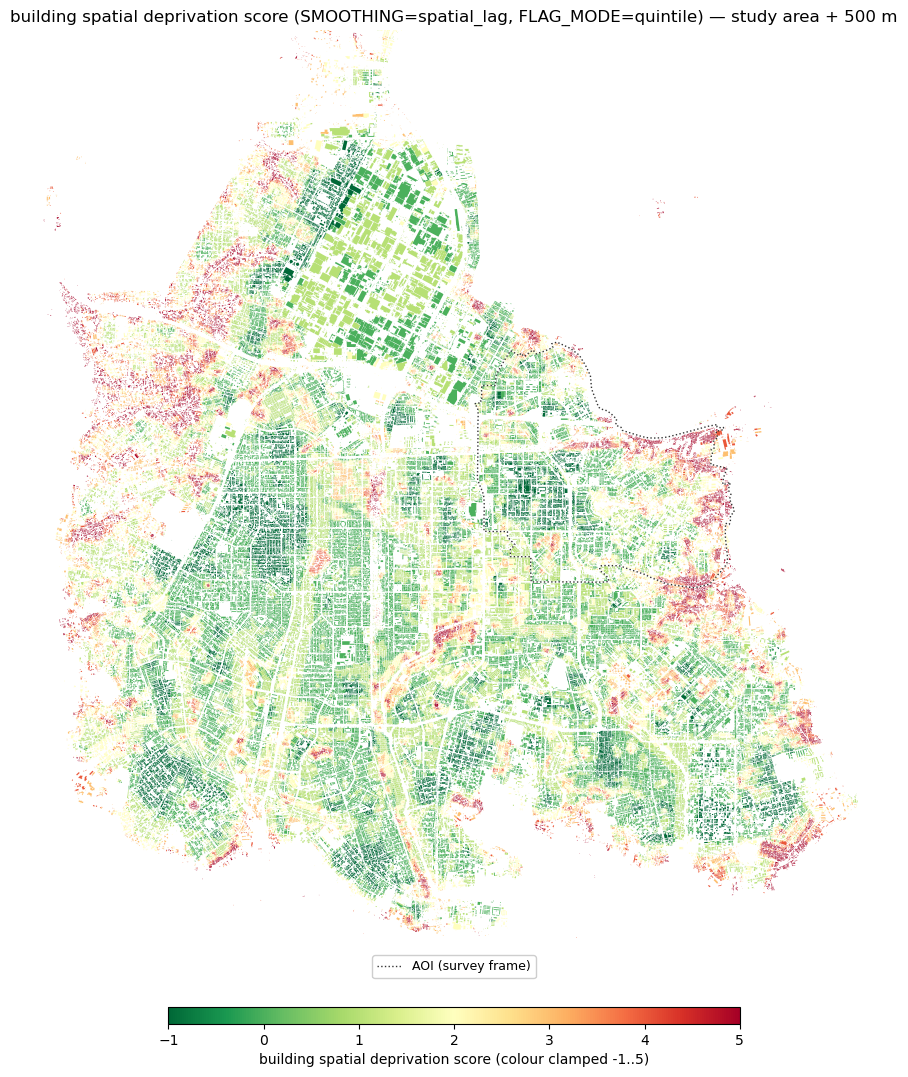

In [7]:
minx, miny, maxx, maxy = blocks.total_bounds
xlim = (minx - BUFFER_M, maxx + BUFFER_M); ylim = (miny - BUFFER_M, maxy + BUFFER_M)
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(13, 12))
bld.plot(column='score', ax=ax, cmap='RdYlGn_r', vmin=-1, vmax=5, markersize=2, linewidth=0,
         legend=True, legend_kwds=dict(orientation='horizontal', shrink=0.45, pad=0.02, aspect=35,
                                       label='building spatial deprivation score (colour clamped -1..5)'))
aoi.boundary.plot(ax=ax, color='#333', linewidth=1.0, linestyle=':', zorder=3)
ax.legend(handles=[Line2D([0], [0], color='#333', lw=1.0, ls=':', label='AOI (survey frame)')],
          loc='lower center', fontsize=9, framealpha=.95)
ax.set_title(f'building spatial deprivation score (SMOOTHING={SMOOTHING}, FLAG_MODE={FLAG_MODE}) — study area + 500 m',
             fontsize=12)
ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_axis_off()
plt.tight_layout(); plt.show()


## 5. Export

In [8]:
bld_out = 'data/output/buildings_spatial-deprivation-scored.gpkg'
blk_out = 'data/output/blocks_spatial-deprivation-scored.gpkg'
_flagcols = [c for c in bld.columns if c.startswith('flag_')]
keep = ['id', 'block_id', 'score'] + _flagcols + ['geometry']
bld[keep].to_crs(export_crs).to_file(bld_out, layer='buildings_scored', driver='GPKG')

# block-level companion: the MEAN building score per block (granular — no classification applied)
bms = pd.Series(bld['score'].to_numpy(), index=bld['block_id'].to_numpy()).groupby(level=0).mean()
blocks_out = blocks.merge(bms.rename('mean_score'), left_on='block_id', right_index=True, how='left')
blocks_out.to_crs(export_crs).to_file(blk_out, layer='blocks_scored', driver='GPKG')
print('exported:'); print(' ', bld_out, f'({len(bld):,} buildings)'); print(' ', blk_out, f'({len(blocks_out):,} blocks)')


exported:
  data/output/buildings_spatial-deprivation-scored.gpkg (200,237 buildings)
  data/output/blocks_spatial-deprivation-scored.gpkg (3,397 blocks)


---

## Part B — survey-cluster representativity

Assesses how well the **survey cluster areas** represent the urban habitat of the study area (AOI). Habitat is
measured with the building-level **spatial deprivation score** produced in Part A above.

## Where the cluster areas come from

They were produced in two stages:

1. a **random draw of street segments** across the AOI yielded 30 candidate paths, steered by a coarse,
   manually drawn framework of urban habitat (from field visits and consultations with local partners) —
   documented in **`2_Cluster-draw`**;
2. each candidate was **site-verified and delineated by hand into a cluster area**: 22 of the 30 were delineated
   *in place*, around their drawn path, and 8 were **displaced following explicit criteria** (fringe position,
   lock-in between ineligible areas, field re-categorization of the surrounding area, spatial balance), all
   traceable through the final layer's 1:1 `path_id` link to the originating paths — see notebook `2` §3.

Stage 2 is therefore a **criteria-based manual adjustment of a random draw** — the realised selection is best
described as **quasi-random**, not as a pure probability draw and not as a free-hand purposive pick either.
§2 shows what it did with the draw; everything after depends on the consequence below.

## What this means for the numbers here

Even though the manual stage was small and rule-governed, the **probability of any given building falling
inside a cluster area is not known and cannot be reconstructed** (displacement destinations were chosen by
judgement, one balance criterion is explicitly qualitative, and the drawn seeds themselves were proportional to
mapped street density, which under-represents informal fabric in OpenStreetMap). Therefore:

- **This notebook is an *audit*, not a validation of a probability design.** It asks a descriptive question —
  *do the cluster areas span the range of urban habitat found in the AOI, or do they concentrate on part of it?*
- **The coverage ratios below are not survey weights.** They describe how much of each habitat the cluster areas
  happen to contain. They are not inverse inclusion probabilities and must not be used to weight estimates.
- **The measures that remain valid are those that need no probabilities:** the **representation ratio** and the
  **dissimilarity index** (§3), which simply compare the habitat mix of the cluster areas with that of the AOI.

The defensible statement this notebook supports is: *the cluster areas come from a random draw refined by
documented, criteria-based field adjustments (quasi-random); the audit below shows how closely their urban
habitat mix matches the AOI.*

## Definitions

| Term | Meaning |
|---|---|
| **AOI** | the study area defined by `new_aoi.shp` |
| **AOI buildings** | buildings whose representative point lies inside the AOI |
| **Covered** | AOI buildings that fall inside a cluster area |
| **Spatial deprivation score** | building score from Part A: a sum of directional morphological / night-light flags, **−1 … 8**; higher = more deprived, more irregular fabric |
| **Coverage %** | covered ÷ AOI buildings, within a score bin — a descriptive coverage rate |
| **Representation ratio (RR)** | (share of covered buildings in a bin) ÷ (share of AOI buildings in that bin). **1.0 = the cluster areas mirror the AOI**; >1 over-represented, <1 under-represented |
| **Dissimilarity index (D)** [4] | half the summed absolute difference between the two distributions = the share of covered buildings that would have to sit in a different score bin for the mix to mirror the AOI. **0% = a perfect mirror** |

## 6 · Inputs

In [9]:
aoi_union = aoi.geometry.union_all()
print(f"AOI: {aoi.area.sum()/1e6:.2f} km2")

# Scored buildings, restricted to the AOI by representative point
bld = gpd.read_parquet(BUILDINGS_FP, columns=["id", "score", "geometry"],
                       bbox=tuple(aoi.total_bounds)).to_crs(local_crs)  # was read_file (.gpkg)
bld = bld[bld.geometry.representative_point().within(aoi_union)].reset_index(drop=True)
n_unscored = int(bld["score"].isna().sum())
bld = bld[bld["score"].notna()].copy()
bld["score"] = bld["score"].astype(int)
SCORES = list(range(int(bld["score"].min()), int(bld["score"].max()) + 1))
print(f"buildings in the AOI with a spatial deprivation score: {len(bld):,}"
      + (f"   (excluded, no score: {n_unscored:,})" if n_unscored else ""))
print(f"score range: {SCORES[0]} to {SCORES[-1]}")

# Cluster areas
cl = gpd.read_file(CLUSTERS_FP).to_crs(local_crs)
cl_union = cl.geometry.union_all()
bld["covered"] = bld.geometry.representative_point().within(cl_union)
print(f"\ncluster areas: {len(cl)}   (total {cl.area.sum()/1e4:.0f} ha)")
print(f"AOI buildings inside a cluster area: {int(bld['covered'].sum()):,} / {len(bld):,} "
      f"({100*bld['covered'].mean():.1f}%)")

AOI: 7.08 km2


buildings in the AOI with a spatial deprivation score: 22,208
score range: -1 to 8

cluster areas: 30   (total 143 ha)
AOI buildings inside a cluster area: 5,143 / 22,208 (23.2%)


## 7 · Survey areas

The map shows the **delineated cluster areas, coloured by their field-verified stratum (`strate`)**, over the
buildings coloured by the **spatial deprivation score of Part A** — the clusters in their measured morphological
context.

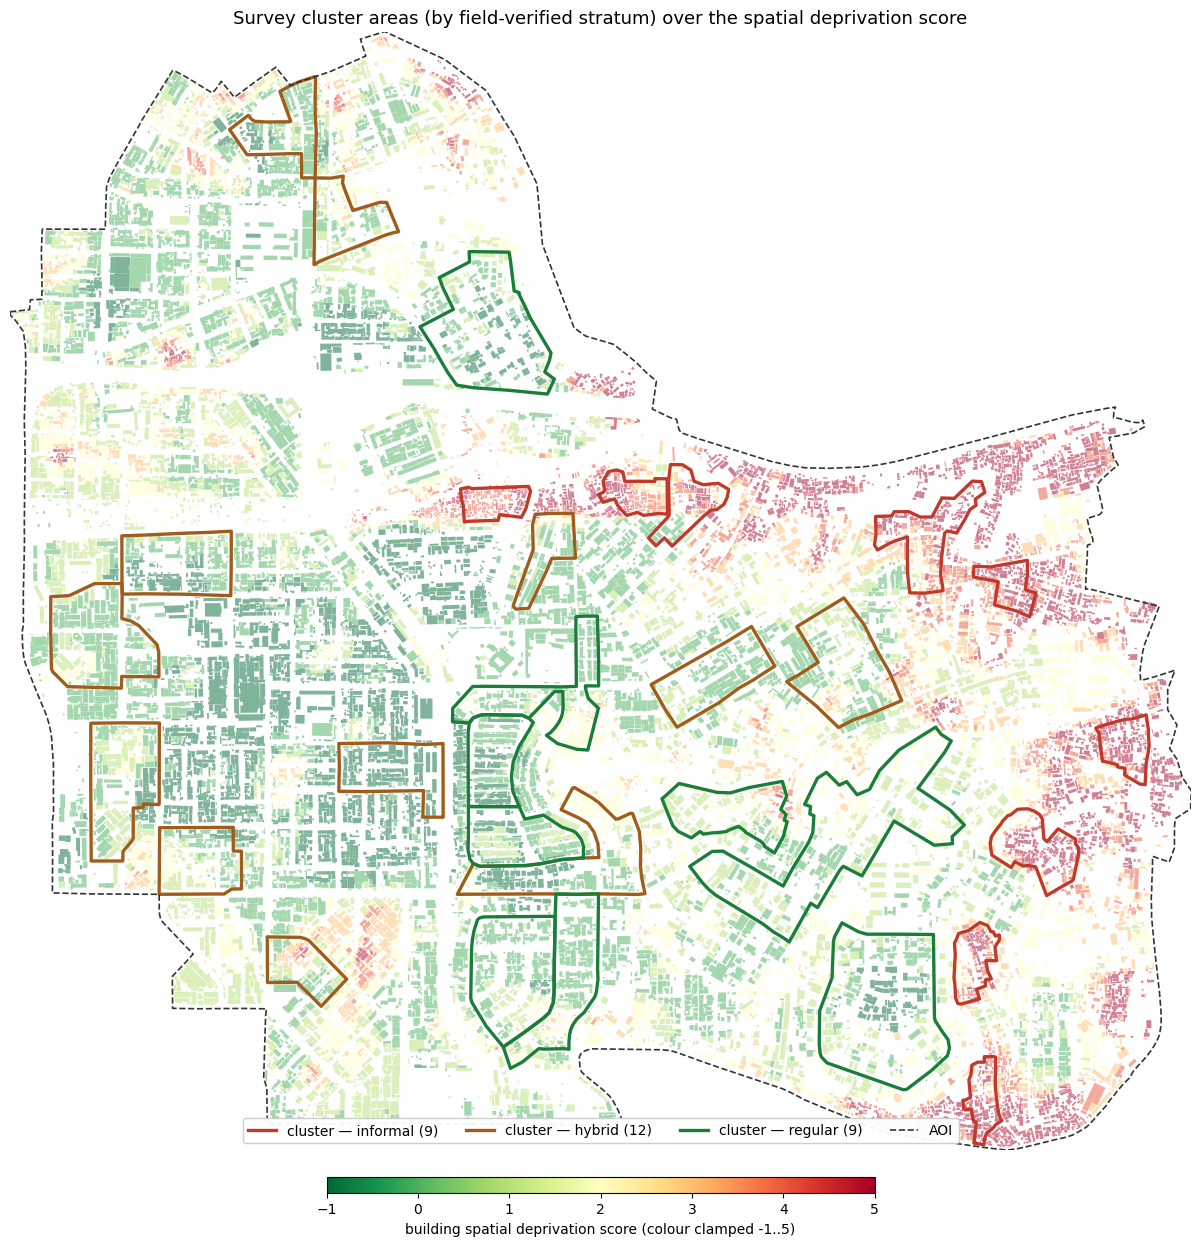

In [10]:
# ── The delineated cluster areas over the scored buildings ──────────────────
STRATE_COL = {"precaire": "#c0392b", "hybride": "#a05c1a", "reguliere": "#1a7d3a"}
STRATE_EN  = {"precaire": "informal", "hybride": "hybrid", "reguliere": "regular"}

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 14))
bld.plot(column="score", ax=ax, cmap="RdYlGn_r", vmin=-1, vmax=5, markersize=2, linewidth=0, zorder=1,
         alpha=0.5,
         legend=True, legend_kwds=dict(orientation="horizontal", shrink=0.4, pad=0.02, aspect=35,
                                       label="building spatial deprivation score (colour clamped -1..5)"))
for s, c in STRATE_COL.items():
    sub = cl[cl["strate"] == s]
    if not sub.empty:
        sub.plot(ax=ax, facecolor="none", edgecolor=c, linewidth=2.4, zorder=3)
aoi.boundary.plot(ax=ax, color="#333", linewidth=1.2, linestyle="--", zorder=4)

handles = [Line2D([0], [0], color=c, lw=2.4, label=f"cluster — {STRATE_EN[s]} ({int((cl['strate']==s).sum())})")
           for s, c in STRATE_COL.items()]
handles.append(Line2D([0], [0], color="#333", lw=1.2, ls="--", label="AOI"))
ax.legend(handles=handles, loc="lower center", ncol=4, fontsize=10, framealpha=.95)
ax.set_title("Survey cluster areas (by field-verified stratum) over the spatial deprivation score", fontsize=13)
ax.set_xlim(aoi.total_bounds[0], aoi.total_bounds[2])
ax.set_ylim(aoi.total_bounds[1], aoi.total_bounds[3])
ax.set_axis_off(); plt.tight_layout(); plt.show()

### The two generations of habitat reference, and whether they agree

The draw was steered by a **manually drawn, expert framework**: three coarse habitat areas sketched from punctual
field visits and consultations with local partners — approximate, but a fair picture of the global geography of
urban habitat in the AOI.

The score used in Part B is the **later, measured successor** of that framework: the detection of informal
fabric from Earth observation was refined through empirical testing and field verification (notebook `1` + Part A)
into a graded score computed from building morphometrics and night-time light.

They are built from different evidence — local knowledge versus remote sensing — so their agreement is
informative. The check below asks whether the score, computed here, recovers the habitat geography that was
sketched by hand before the fieldwork.

In [11]:
# ── Does the current score recover the original expert habitat geography? ────
ref = gpd.read_file(HABITAT_REF_FP).to_crs(local_crs)
_lab = pd.Series(index=bld.index, dtype=object)
_rp = bld.geometry.representative_point()
for r in ref.itertuples():
    _lab[_rp.within(r.geometry)] = r.habitat
bld["expert_class"] = _lab

_sub = bld[bld["expert_class"].notna()]
_g = _sub.groupby("expert_class")["score"].agg(["count", "mean", "median"]).reindex(["regular", "hybrid", "informal"])
print(f"buildings inside the original expert habitat areas: {len(_sub):,}\n")
print("current spatial deprivation score, by the ORIGINAL expert habitat class:")
print(_g.round(2).to_string())
print(f"\nmean score rises monotonically regular -> hybrid -> informal: "
      f"{' -> '.join(f'{v:.2f}' for v in _g['mean'])}")
print("\n-> the two generations agree on the global geography: the score, computed from morphometrics and\n"
      "   night-time light, independently reproduces the habitat pattern sketched from local knowledge.")
print("\nCaveat: the agreement is not fully independent. The score's flags come from Earth observation, but its\n"
      "development was steered and validated against field-verified blocks, and the expert sketch also drew on field knowledge — so\n"
      "the two share an information source. The ORDERING of the mean scores is the robust part of this result.")

buildings inside the original expert habitat areas: 17,918

current spatial deprivation score, by the ORIGINAL expert habitat class:
              count  mean  median
expert_class                     
regular        3706  0.44     0.0
hybrid         9306  0.94     1.0
informal       4906  3.95     4.0

mean score rises monotonically regular -> hybrid -> informal: 0.44 -> 0.94 -> 3.95

-> the two generations agree on the global geography: the score, computed from morphometrics and
   night-time light, independently reproduces the habitat pattern sketched from local knowledge.

Caveat: the agreement is not fully independent. The score's flags come from Earth observation, but its
development was steered and validated against field-verified blocks, and the expert sketch also drew on field knowledge — so
the two share an information source. The ORDERING of the mean scores is the robust part of this result.


### Mean spatial deprivation score per survey stratum

The table below summarises the **mean spatial deprivation score of the buildings inside the delineated
cluster areas, grouped by the clusters' field-verified stratum** (`strate`). It provides the per-stratum
figures reported in the protocol paper. Note what the score can and cannot separate here: the **informal**
stratum stands far above the other two, while **hybrid and regular are near-indistinguishable on the score**
(both medians at 0) — consistent with the score being a measure of *spatial deprivation*, which concentrates
in informal fabric, and with the hybrid/regular distinction being a field-verified judgement rather than a
score-derived one.


In [12]:
# ── Mean spatial deprivation score per field-verified survey stratum ─────────
# Assign each covered building to the cluster area that contains it, then group by the cluster's stratum.
_rp = bld.geometry.representative_point()
_stratum = pd.Series(index=bld.index, dtype=object)
for r in cl.itertuples():
    _stratum[_rp.within(r.geometry)] = STRATE_EN[r.strate]

bld["survey_stratum"] = _stratum
_in = bld[bld["survey_stratum"].notna()]

stratum_scores = (_in.groupby("survey_stratum")["score"]
                     .agg(n_buildings="count", mean="mean", median="median", std="std")
                     .reindex(["informal", "hybrid", "regular"]))

print(f"buildings inside a cluster area, by field-verified stratum: {len(_in):,}\n")
print("spatial deprivation score of covered buildings, by survey stratum:")
print(stratum_scores.round(2).to_string())
print(f"\nAOI-wide mean score (all {len(bld):,} scored buildings): {bld['score'].mean():.2f}")
_m = stratum_scores["mean"]
print(f"\n-> the informal stratum stands far above the other two on the measured score "
      f"(informal {_m['informal']:.2f} vs hybrid {_m['hybrid']:.2f} / regular {_m['regular']:.2f});")
print("   hybrid and regular are near-indistinguishable on the score (both medians 0) - the score measures")
print("   spatial deprivation, which concentrates in informal fabric; the hybrid/regular distinction is a")
print("   field-verified judgement, not a score-derived one.")


buildings inside a cluster area, by field-verified stratum: 5,143

spatial deprivation score of covered buildings, by survey stratum:
                n_buildings  mean  median   std
survey_stratum                                 
informal               1312  4.37     4.0  1.41
hybrid                 1931  0.43     0.0  1.08
regular                1900  0.48     0.0  1.02

AOI-wide mean score (all 22,208 scored buildings): 1.65

-> the informal stratum stands far above the other two on the measured score (informal 4.37 vs hybrid 0.43 / regular 0.48);
   hybrid and regular are near-indistinguishable on the score (both medians 0) - the score measures
   spatial deprivation, which concentrates in informal fabric; the hybrid/regular distinction is a
   field-verified judgement, not a score-derived one.


## 8 · Habitat mix of the clusters vs the AOI

`coverage_pct` is the share of the AOI's buildings in each score bin that fall inside a cluster area.
`rep_ratio` compares the two distributions and is the key representativity measure — it needs no assumption
about how buildings were selected. `coverage_ratio` (= 1/coverage) is shown for reference only; as explained in
the header, **it is not a survey weight**.

The **dissimilarity index D** summarises each comparison in one number: the share of sampled buildings that
would have to change bins for the clusters to mirror the AOI exactly. The same index travels across fields
under different names — it is the *index of dissimilarity* of segregation research [4] and, computed on
two profiles normalised to a common total, it is **mathematically identical to the Bray–Curtis
dissimilarity** of community ecology [5]; its complement is Renkonen's percentage-similarity index [6].
The audit itself follows the logic of **representativeness assessments of environmental sampling
networks** [7], which ask the same question of a set of sampling sites and the landscape they are meant
to represent.

⚠ **There is no established threshold for a "good" D.** Segregation research conventionally reads values
below 30 as *low* [8, p. 20], but that convention is specific to that field, and ecology
uses Bray–Curtis [5] comparatively — between samples, in ordination — rather than against an absolute
cut. The
bands are quoted here as a rough heuristic only: what counts as acceptable depends on the quantity being
estimated, not on the index. The defensible readings are **relative** ones — one axis against another, or
against the score axis (§11).


In [13]:
n_aoi = bld.groupby("score").size().reindex(SCORES, fill_value=0)
n_cov = bld[bld["covered"]].groupby("score").size().reindex(SCORES, fill_value=0)

tab = pd.DataFrame({"score": SCORES, "n_aoi": n_aoi.values, "n_covered": n_cov.values}).set_index("score")
tab["pct_of_aoi"]      = 100 * tab["n_aoi"]     / tab["n_aoi"].sum()
tab["pct_of_covered"]  = 100 * tab["n_covered"] / tab["n_covered"].sum()
tab["coverage_pct"]    = 100 * tab["n_covered"] / tab["n_aoi"].replace(0, np.nan)
tab["rep_ratio"]       = tab["pct_of_covered"] / tab["pct_of_aoi"].replace(0, np.nan)
tab["coverage_ratio"]  = tab["n_aoi"] / tab["n_covered"].replace(0, np.nan)

print(tab.round({"pct_of_aoi": 2, "pct_of_covered": 2, "coverage_pct": 2,
                 "rep_ratio": 2, "coverage_ratio": 1}).to_string())

D        = 0.5 * np.nansum(np.abs(tab["pct_of_covered"] - tab["pct_of_aoi"]))
mean_aoi = np.average(tab.index, weights=tab["n_aoi"])
mean_cov = np.average(tab.index, weights=tab["n_covered"])
print(f"\noverall coverage              : {100*tab['n_covered'].sum()/tab['n_aoi'].sum():.2f}% of AOI buildings")
print(f"mean spatial deprivation score: AOI {mean_aoi:.2f}  vs  clusters {mean_cov:.2f}   ({mean_cov-mean_aoi:+.2f})")
print(f"dissimilarity index D         : {D:.1f}%   (0% = the clusters mirror the AOI habitat mix)")

       n_aoi  n_covered  pct_of_aoi  pct_of_covered  coverage_pct  rep_ratio  coverage_ratio
score                                                                                       
-1      2449        605       11.03           11.76         24.70       1.07             4.0
 0      5633       1690       25.36           32.86         30.00       1.30             3.3
 1      4270        976       19.23           18.98         22.86       0.99             4.4
 2      3401        556       15.31           10.81         16.35       0.71             6.1
 3      2026        258        9.12            5.02         12.73       0.55             7.9
 4      1684        399        7.58            7.76         23.69       1.02             4.2
 5      1513        385        6.81            7.49         25.45       1.10             3.9
 6      1037        220        4.67            4.28         21.22       0.92             4.7
 7       194         54        0.87            1.05         27.84     

## 9 · Number of buildings by spatial deprivation score

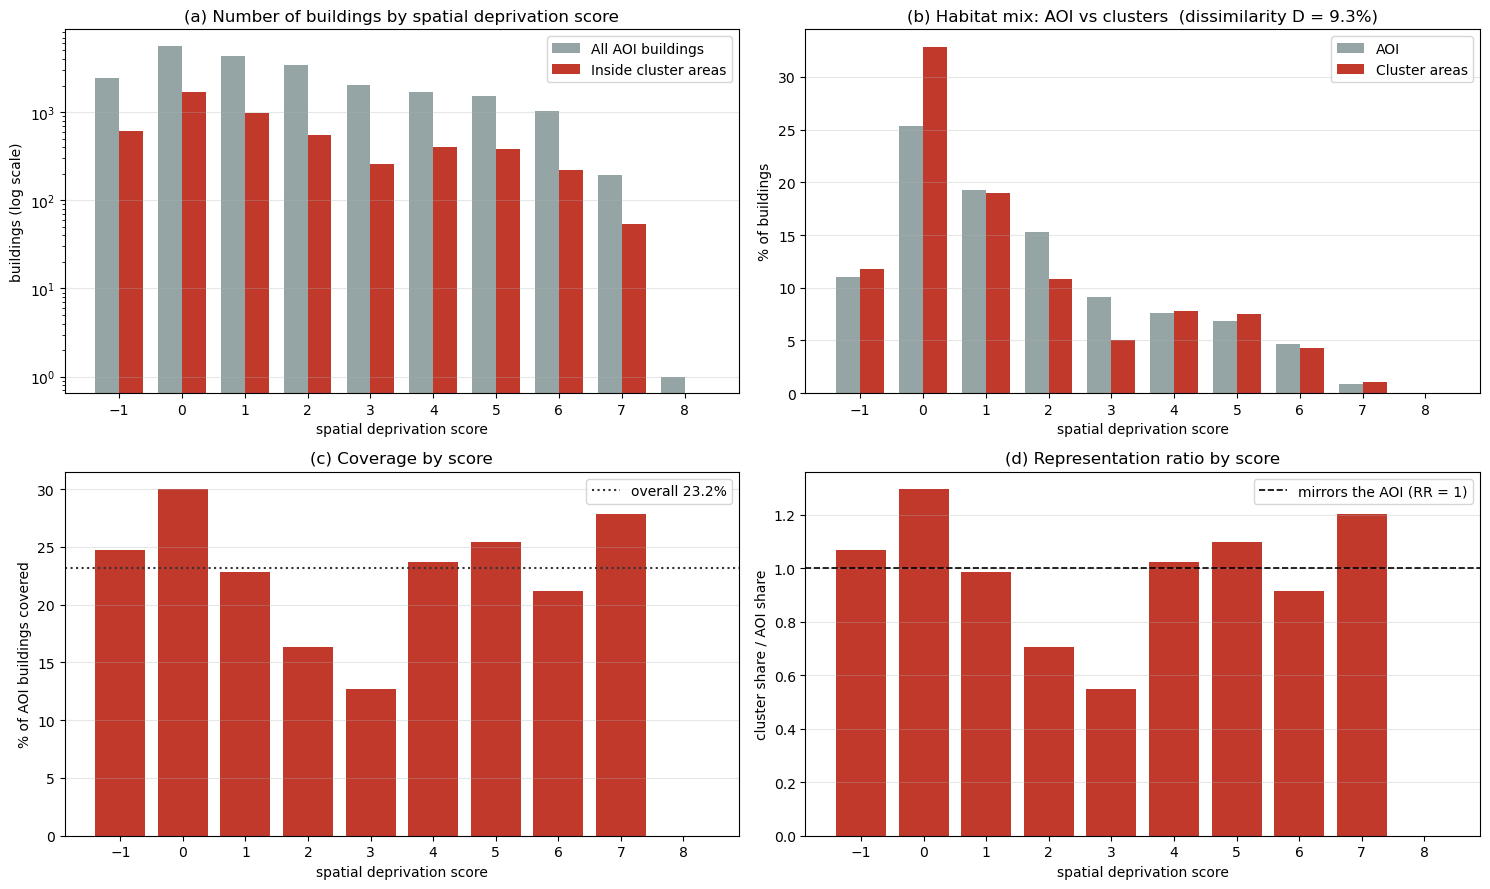

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))
x = np.array(SCORES); w = 0.38
COV, AOI_C = "#c0392b", "#95a5a6"

a = ax[0, 0]
a.bar(x - w/2, tab["n_aoi"],     w, label="All AOI buildings", color=AOI_C)
a.bar(x + w/2, tab["n_covered"], w, label="Inside cluster areas", color=COV)
a.set_yscale("log"); a.set_xticks(x); a.grid(alpha=.3, axis="y"); a.legend()
a.set_xlabel("spatial deprivation score"); a.set_ylabel("buildings (log scale)")
a.set_title("(a) Number of buildings by spatial deprivation score")

a = ax[0, 1]
a.bar(x - w/2, tab["pct_of_aoi"],     w, label="AOI", color=AOI_C)
a.bar(x + w/2, tab["pct_of_covered"], w, label="Cluster areas", color=COV)
a.set_xticks(x); a.grid(alpha=.3, axis="y"); a.legend()
a.set_xlabel("spatial deprivation score"); a.set_ylabel("% of buildings")
a.set_title(f"(b) Habitat mix: AOI vs clusters  (dissimilarity D = {D:.1f}%)")

a = ax[1, 0]
a.bar(x, tab["coverage_pct"], color=COV)
_ov = 100*tab["n_covered"].sum()/tab["n_aoi"].sum()
a.axhline(_ov, ls=":", color="#333", label=f"overall {_ov:.1f}%")
a.set_xticks(x); a.grid(alpha=.3, axis="y"); a.legend()
a.set_xlabel("spatial deprivation score"); a.set_ylabel("% of AOI buildings covered")
a.set_title("(c) Coverage by score")

a = ax[1, 1]
a.bar(x, tab["rep_ratio"], color=COV)
a.axhline(1.0, color="black", lw=1.2, ls="--", label="mirrors the AOI (RR = 1)")
a.set_xticks(x); a.grid(alpha=.3, axis="y"); a.legend()
a.set_xlabel("spatial deprivation score"); a.set_ylabel("cluster share / AOI share")
a.set_title("(d) Representation ratio by score")

plt.tight_layout(); plt.show()

## 10 · The wider frame: Yopougon as a whole (for an eventual expansion)

The clusters were drawn for the AOI — the frame of the HDSS. An eventual **expansion** of the HDSS and its
surveys would sample from a wider frame, so the audit is repeated here against **all scored buildings** — the
study area of notebooks `1`/`3a` (Yopougon-Attécoubé), roughly ten times the AOI.

⚠ Against this frame, *coverage* percentages are not meaningful: the clusters lie inside the AOI by design and
can only ever cover a sliver of the wider frame. What is meaningful is the **distribution** — do the buildings
inside the cluster areas span the range of built environments found across Yopougon, and in what proportions?
The table therefore reports habitat-mix shares, representation ratios and the dissimilarity index only.


       n_yopougon  n_covered  pct_of_yopougon  pct_of_covered  rep_ratio
score                                                                   
-1          16995        605             8.49           11.76       1.39
 0          54148       1690            27.04           32.86       1.22
 1          50960        976            25.45           18.98       0.75
 2          32308        556            16.13           10.81       0.67
 3          19992        258             9.98            5.02       0.50
 4          12799        399             6.39            7.76       1.21
 5           8340        385             4.17            7.49       1.80
 6           4009        220             2.00            4.28       2.14
 7            660         54             0.33            1.05       3.19
 8             26          0             0.01            0.00       0.00

scored buildings in the wider frame: 200,237   (the AOI holds 22,208 = 11.1% of them)
mean spatial deprivation score: Yopou

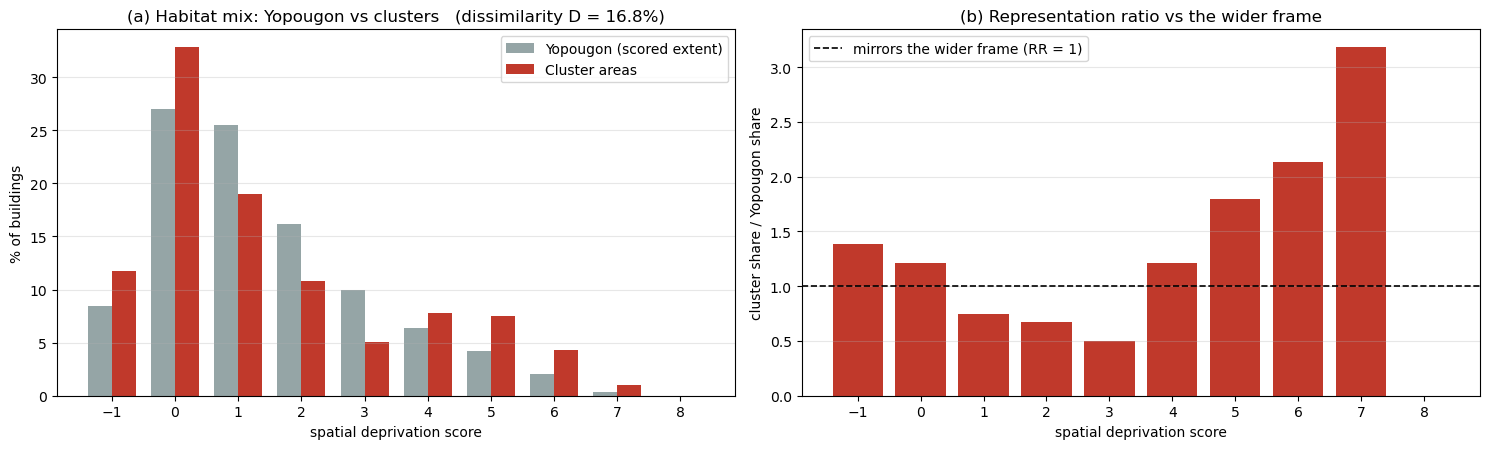

In [15]:
bld_yop = gpd.read_parquet(BUILDINGS_FP, columns=["id", "score", "geometry"]).to_crs(local_crs)  # was read_file (.gpkg)
bld_yop = bld_yop[bld_yop["score"].notna()].copy(); bld_yop["score"] = bld_yop["score"].astype(int)
SC_Y = sorted(set(SCORES) | set(range(int(bld_yop["score"].min()), int(bld_yop["score"].max()) + 1)))

n_yop  = bld_yop.groupby("score").size().reindex(SC_Y, fill_value=0)
n_cov2 = bld[bld["covered"]].groupby("score").size().reindex(SC_Y, fill_value=0)
tj = pd.DataFrame({"n_yopougon": n_yop.values, "n_covered": n_cov2.values}, index=pd.Index(SC_Y, name="score"))
tj["pct_of_yopougon"] = 100 * tj["n_yopougon"] / tj["n_yopougon"].sum()
tj["pct_of_covered"]  = 100 * tj["n_covered"]  / tj["n_covered"].sum()
tj["rep_ratio"]       = tj["pct_of_covered"] / tj["pct_of_yopougon"].replace(0, np.nan)
print(tj.round({"pct_of_yopougon": 2, "pct_of_covered": 2, "rep_ratio": 2}).to_string())

D_y      = 0.5 * np.nansum(np.abs(tj["pct_of_covered"] - tj["pct_of_yopougon"]))
mean_yop = np.average(tj.index, weights=tj["n_yopougon"])
mean_cv2 = np.average(tj.index, weights=tj["n_covered"])
print(f"\nscored buildings in the wider frame: {len(bld_yop):,}   (the AOI holds {len(bld):,} = "
      f"{100*len(bld)/len(bld_yop):.1f}% of them)")
print(f"mean spatial deprivation score: Yopougon {mean_yop:.2f}  vs  clusters {mean_cv2:.2f}   ({mean_cv2-mean_yop:+.2f})")
print(f"dissimilarity index D         : {D_y:.1f}%   (0% = the clusters mirror the habitat mix of the wider frame)")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
x = np.array(SC_Y); w = 0.38
ax[0].bar(x - w/2, tj["pct_of_yopougon"], w, label="Yopougon (scored extent)", color="#95a5a6")
ax[0].bar(x + w/2, tj["pct_of_covered"],  w, label="Cluster areas", color="#c0392b")
ax[0].set_xticks(x); ax[0].grid(alpha=.3, axis="y"); ax[0].legend()
ax[0].set_xlabel("spatial deprivation score"); ax[0].set_ylabel("% of buildings")
ax[0].set_title(f"(a) Habitat mix: Yopougon vs clusters   (dissimilarity D = {D_y:.1f}%)")
ax[1].bar(x, tj["rep_ratio"], color="#c0392b")
ax[1].axhline(1.0, color="black", lw=1.2, ls="--", label="mirrors the wider frame (RR = 1)")
ax[1].set_xticks(x); ax[1].grid(alpha=.3, axis="y"); ax[1].legend()
ax[1].set_xlabel("spatial deprivation score"); ax[1].set_ylabel("cluster share / Yopougon share")
ax[1].set_title("(b) Representation ratio vs the wider frame")
plt.tight_layout(); plt.show()


## 11 · A stronger test: axes the selection never balanced on

§8–§10 audit the clusters along the spatial deprivation score — an axis *related* to what steered the cluster
selection (see the last note in §12). This section runs the harder version of the same audit: it compares
the clusters against the AOI on **raw habitat variables that no one balanced on when delineating the
cluster areas**. If those distributions agree, the agreement cannot be an artefact of the habitat-guided
selection; if an axis disagrees, that is a documented caveat for analyses using it.

**Four of the score's nine signals qualify.** They are used here **raw and unlagged** — the per-building
measurements, not the smoothed versions that feed the score (where each enters only as a coarse binary flag):

- `nnb_50m` — **building density** (neighbours within 50 m);
- `building_area` — **structure size** (footprint area);
- `ntl_nearest` — **night-time lights** (VIIRS radiance; a raster no one consulted during delineation —
  note that its dimmest values mark uninhabited open/green/blue land as much as unlit dwellings);
- `nb_alignment_knn4` — **layout irregularity** (mean orientation deviation from the 4 nearest neighbours).

**The other five signals are excluded, each for a structural reason:**

- `dist_to_waterway` — water proximity **was an explicit criterion** of the sampling design (waterway /
  lagoon proximity quotas), so it is precisely an axis the selection *did* consider: auditing it tests nothing.
- `dist_to_street`, `str_align`, `node_meshedness` — **mechanically entangled with the sampling instrument**:
  the clusters are street-based objects (drawn from a random draw of street segments and delineated along
  streets), so sampled buildings are close to — and aligned with — streets by construction. Deviations on
  these axes would reflect the instrument's geometry, not the selection; the test would be confounded either way.
- `std_building_area` — **not a per-building measurement** but an order-3 neighbourhood statistic: its
  distribution is pre-smoothed and spatially autocorrelated, so distributional comparison is much blurrier.

Two honest caveats on the retained axes: `nb_alignment_knn4` is the axis closest to the visual criterion of
the expert habitat classification (layout regularity), so agreement on it is weaker evidence than on the
other three; and `nnb_50m` interacts mildly with the original growth rule (candidate clusters were extended
until they held enough buildings) — a rule that affected cluster *length*, not which density strata were picked.

**Method** — same machinery as §8, with AOI deciles playing the role of the score bins: each axis is cut at
the deciles of its AOI distribution, the clusters' share per decile is compared with the AOI's share
(representation ratio) and summarised by the dissimilarity index **D**, alongside the mean and median shift.
Because these axes are continuous, D is reported next to the **Kolmogorov–Smirnov statistic [9,10]** — the largest
gap between the two empirical CDFs, which needs no binning choice and is the measure used in the
sampling-network representativeness literature [7]. The figure overlays the two ECDFs per axis.

⚠ Both are reported as **descriptive distances, without p-values**. The clusters' buildings are a *subset* of
the AOI's rather than an independent sample; buildings are strongly spatially autocorrelated, so they are far
from the independent observations a test assumes; and at n ≈ 22,000 any test would return significance for
differences far too small to matter. The magnitudes are the evidence here, not significance.


In [16]:
# ── §11 · Audit each selection-independent axis against the clusters ─────────────────────────
AXES = {'nnb_50m':            'building density (neighbours within 50 m)',
        'building_area':      'structure size (footprint, m2)',
        'ntl_nearest':        'night-time lights (VIIRS radiance)',
        'nb_alignment_knn4':  'layout irregularity (KNN-4 orientation deviation, deg)'}

bldx = bld.merge(raw_axes, on='id', how='left', validate='one_to_one')
n_miss = int(bldx[list(AXES)].isna().any(axis=1).sum())
print(f"AOI buildings with all four axis values: {len(bldx) - n_miss:,} / {len(bldx):,}"
      + (f"   (missing on some axis: {n_miss:,})" if n_miss else ""))

def ks_statistic(a, b):
    """Largest gap between two empirical CDFs (Kolmogorov-Smirnov statistic) - a descriptive distance, no test."""
    a, b = np.sort(a), np.sort(b)
    v = np.unique(np.concatenate([a, b]))
    return float(np.max(np.abs(np.searchsorted(a, v, side='right') / len(a)
                               - np.searchsorted(b, v, side='right') / len(b))))

summary = []
for var, label in AXES.items():
    x = bldx[[var, 'covered']].dropna(subset=[var])
    edges = np.unique(np.nanpercentile(x[var], np.arange(0, 101, 10)))
    b_all = pd.cut(x[var], edges, include_lowest=True)
    t = pd.DataFrame({'pct_of_aoi':     100 * b_all.value_counts(sort=False, normalize=True),
                      'pct_of_covered': 100 * b_all[x['covered']].value_counts(sort=False, normalize=True)})
    t['rep_ratio'] = t['pct_of_covered'] / t['pct_of_aoi'].replace(0, np.nan)
    D = 0.5 * np.nansum(np.abs(t['pct_of_covered'] - t['pct_of_aoi']))
    ks = ks_statistic(x[var].to_numpy(), x.loc[x['covered'], var].to_numpy())
    m_aoi, m_cov  = x[var].mean(),   x.loc[x['covered'], var].mean()
    md_aoi, md_cov = x[var].median(), x.loc[x['covered'], var].median()
    summary.append({'axis': var, 'D_pct': D, 'KS': ks, 'mean_aoi': m_aoi, 'mean_clusters': m_cov,
                    'median_aoi': md_aoi, 'median_clusters': md_cov, 'n_bins': len(t)})
    print(f"\n{'-'*30} {label} {'-'*30}")
    print(t.round(2).to_string())
    print(f"dissimilarity D = {D:.1f}%   KS = {ks:.3f}   mean AOI {m_aoi:.2f} vs clusters {m_cov:.2f}   "
          f"median {md_aoi:.2f} vs {md_cov:.2f}")

summary = pd.DataFrame(summary).set_index('axis')
D_score = 0.5 * np.nansum(np.abs(tab['pct_of_covered'] - tab['pct_of_aoi']))
print('\n' + '=' * 78)
print(summary.round(2).to_string())
print(f"\nbenchmark - D on the spatial deprivation score itself (Section 8): {D_score:.1f}%")


AOI buildings with all four axis values: 22,208 / 22,208

------------------------------ building density (neighbours within 50 m) ------------------------------
                pct_of_aoi  pct_of_covered  rep_ratio
nnb_50m                                              
(-0.001, 16.0]       11.86           10.81       0.91
(16.0, 20.0]          9.98           10.69       1.07
(20.0, 23.0]          9.06            9.72       1.07
(23.0, 27.0]         11.88           13.26       1.12
(27.0, 30.0]          8.65            9.43       1.09
(30.0, 33.0]          8.70            8.98       1.03
(33.0, 37.0]         10.64            9.72       0.91
(37.0, 42.0]         10.43            7.08       0.68
(42.0, 49.0]          9.55            7.54       0.79
(49.0, 87.0]          9.24           12.76       1.38
dissimilarity D = 7.3%   KS = 0.035   mean AOI 31.25 vs clusters 31.82   median 30.00 vs 29.00

------------------------------ structure size (footprint, m2) ------------------------------
 

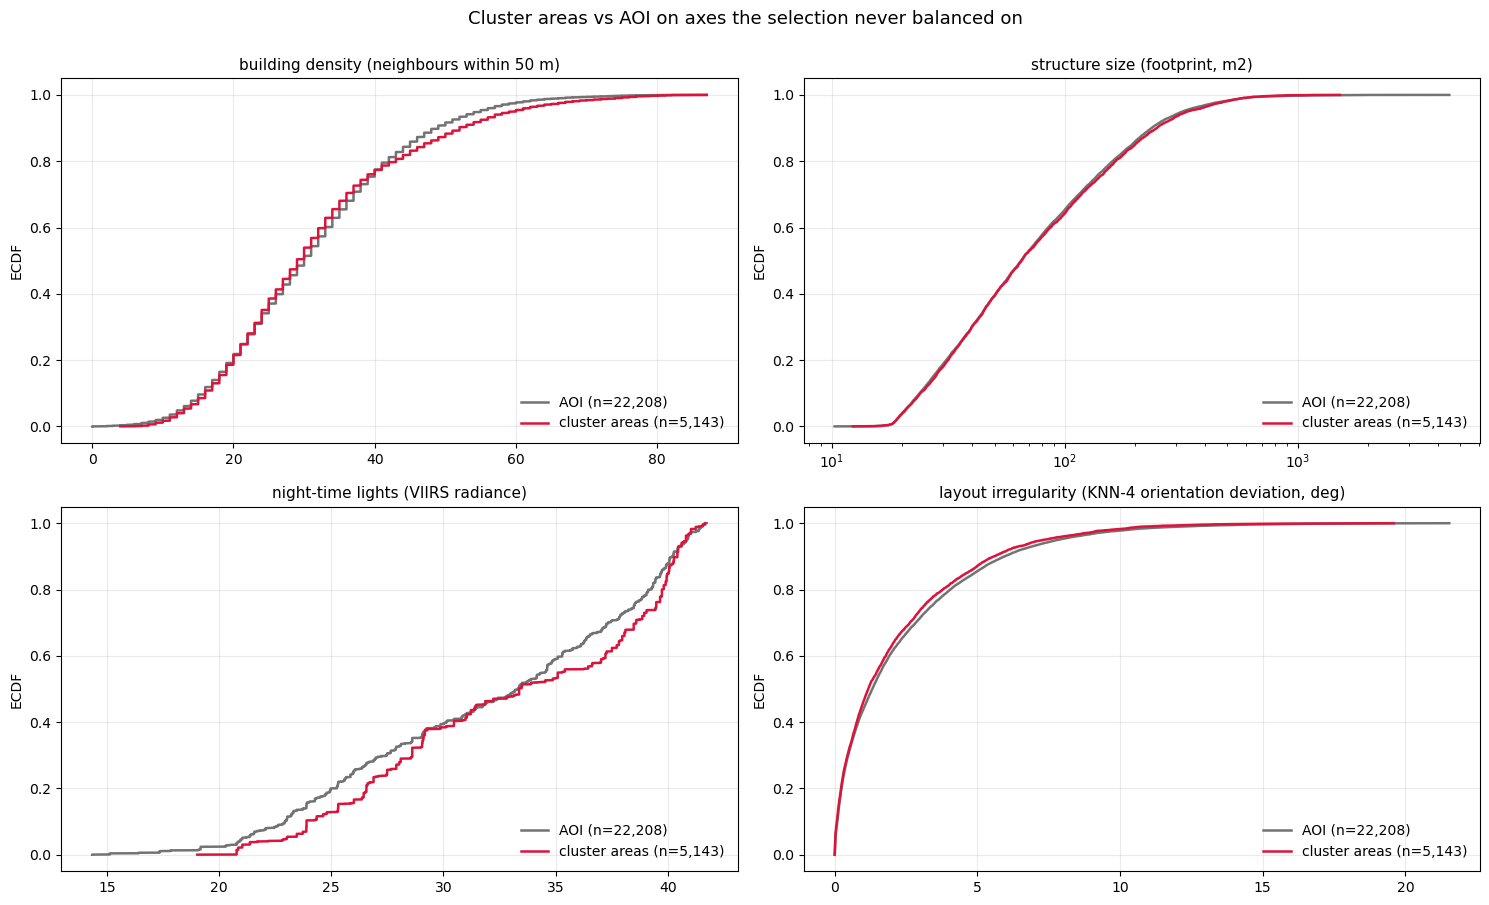

In [17]:
# ── §11 · Empirical CDFs, AOI vs clusters, per axis ──────────────────────────────────────────
fig, axs = plt.subplots(2, 2, figsize=(15, 9))
for ax, (var, label) in zip(axs.ravel(), AXES.items()):
    x = bldx[[var, 'covered']].dropna(subset=[var])
    for mask, name, col in ((np.ones(len(x), bool), 'AOI', '0.45'),
                            (x['covered'].to_numpy(), 'cluster areas', 'crimson')):
        v = np.sort(x.loc[mask, var].to_numpy())
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=col, lw=1.8,
                label=f"{name} (n={len(v):,})")
    if var == 'building_area':
        ax.set_xscale('log')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('ECDF'); ax.legend(frameon=False, loc='lower right')
    ax.grid(alpha=0.25)
fig.suptitle('Cluster areas vs AOI on axes the selection never balanced on', y=1.0, fontsize=13)
plt.tight_layout(); plt.show()


**Reading (this run).** The clusters mirror the AOI closely on three of the four axes — structure size
(D = 1.8%, KS = 0.012), layout irregularity (D = 3.3%, KS = 0.030) and building density (D = 7.4%,
KS = 0.035) — all at or below the score-axis benchmark of 9.0% (§8), with near-identical means and medians.
Night-time lights deviates most on both measures (D = 14.4%, KS = 0.096): the dimmest decile is
under-represented (representation ratio 0.47), though the mean and median essentially coincide with the AOI's.

**The two measures agree on the ordering** — size < irregularity ≈ density ≪ night-lights — so the reading
does not depend on the decile cut, which KS does not use. Their scales differ by construction: D sums the
per-bin discrepancies whatever their sign, while KS reads the largest *cumulative* gap, so deviations that
alternate in sign inflate D but leave KS small. Night-time lights is the only axis whose gap is **cumulative**
(KS 3–8× the others), and it arises at the dim end.

**That dim-end gap is expected, and is not a sampling deficit.** The least-lit parts of the AOI are largely
**uninhabited** — open, green and blue areas — where the few structures present are not dwellings. The cluster
areas were delineated to sample *households*, so they legitimately contain little of that land. The deviation
therefore says more about the **frame** than about the sample: the AOI building set includes structures in
uninhabited areas, which makes it a slightly imperfect proxy for the population the survey targets. The
remainder of the night-lights D, which alternates across the upper deciles rather than accumulating, is
plausibly the coarse VIIRS raster (~154 m pixels): spatially contiguous clusters sample whole pixels, making
decile shares lumpy.

For scale, all four D values sit in the lowest band of the conventional reading of the index (below 30 =
*low* [8]) — see §8 for where that convention comes from and why it is a heuristic, not a threshold.

**Overall: on the axes the selection could not have engineered, the sample tracks the AOI at least as well
as on the spatial deprivation score itself.** This is the stronger form of the §8 result — agreement here cannot be
an artefact of the habitat-guided selection. The single systematic deviation, on night-time lights, resolves
into a property of the frame (uninhabited dark land) rather than a bias of the cluster areas.


## 12 · Notes and caveats

- **The cluster selection is quasi-random** (random draw + documented, criteria-based adjustments — see
  header). These tables are a habitat **audit**; the coverage ratios are **not survey weights** and inclusion
  probabilities are not recoverable.
- **Coverage is geographic, not a household count.** It measures which buildings lie inside a cluster area. It
  is not the number of households interviewed, which depends on the field protocol applied within each cluster.
  The **shape** of coverage across the score range is the informative part, not its absolute level.
- **Two frames on purpose.** §8–§9 audit against the AOI (the frame of the HDSS); §10 against all scored
  buildings (the frame of an eventual expansion). The clusters sit inside the AOI, so only distributional
  measures are compared against the wider frame.
- **Buildings without a score** lie outside any defined block (unbuilt or unblocked land) and are excluded.
- **The yardstick is not identical to what guided the selection, but it is related to it.** The score used here
  post-dates the selection, which was steered by an earlier classification of the same phenomenon and by field
  observation. Agreement is therefore neither circular nor fully independent evidence. §11 therefore audits raw habitat
  variables directly — axes the selection of the cluster areas never balanced on, entering the score only
  as coarse binary flags — where agreement cannot be an artefact of the habitat-guided selection.

---

## References

Numbered by order of first appearance, Vancouver style.

1. Taubenböck H, Kraff NJ, Wurm M. The morphology of the Arrival City — a global categorization based on
   literature surveys and remotely sensed data. Appl Geogr. 2018;92:150-167.
2. Wurm M, Taubenböck H. Detecting social groups from space — assessment of remote sensing-based mapped
   morphological slums using income data. Remote Sens Lett. 2018;9(1):41-50.
3. Fleischmann M, Feliciotti A, Romice O, Porta S. Methodological foundation of a numerical taxonomy of urban
   form. Environ Plan B Urban Anal City Sci. 2022;49(4):1283-1299.
4. Duncan OD, Duncan B. A methodological analysis of segregation indexes. Am Sociol Rev. 1955;20(2):210-217.
5. Bray JR, Curtis JT. An ordination of the upland forest communities of southern Wisconsin. Ecol Monogr.
   1957;27(4):325-349.
6. Renkonen O. Statistisch-ökologische Untersuchungen über die terrestrische Käferwelt der finnischen
   Bruchmoore. Ann Zool Soc Zool-Bot Fenn Vanamo. 1938;6:1-231.
7. Hoffman FM, Kumar J, Mills RT, Hargrove WW. Representativeness-based sampling network design for the State
   of Alaska. Landsc Ecol. 2013;28(8):1567-1586.
8. Massey DS, Denton NA. American Apartheid: Segregation and the Making of the Underclass. Cambridge, MA:
   Harvard University Press; 1993.
9. Kolmogorov A. Sulla determinazione empirica di una legge di distribuzione. G Ist Ital Attuari.
   1933;4:83-91.
10. Smirnov N. Table for estimating the goodness of fit of empirical distributions. Ann Math Stat.
    1948;19(2):279-281.
